In [1]:
import numpy as np
import pandas as pd
College = pd.read_csv("College.csv", index_col=0)
data = College.copy()
data = pd.get_dummies(data, drop_first=True)
y = data['Apps']
X = data.drop(columns=['Apps'])

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


Train size: 543
Test size : 234


In [5]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)
mse_lin = mean_squared_error(y_test, y_pred_lin)

print(f" Linear Regression - Test MSE: {mse_lin:.2f}")


 Linear Regression - Test MSE: 1931803.19


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
alphas = np.logspace(-2, 4, 100)  

ridge = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=alphas, cv=10)
)

ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

best_alpha_ridge = ridge.named_steps['ridgecv'].alpha_

print(f"Ridge - Best λ: {best_alpha_ridge:.4f}")
print(f"Ridge - Test MSE: {mse_ridge:.2f}")


Ridge - Best λ: 2.3101
Ridge - Test MSE: 1863395.23


In [8]:
alphas_lasso = np.logspace(-3, 1, 100)

lasso = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=alphas_lasso, cv=10, random_state=42, max_iter=10000)
)

lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

lasso_cv = lasso.named_steps['lassocv']
best_alpha_lasso = lasso_cv.alpha_

# Lasso 的係數（含所有 predictors）
coef_lasso = lasso_cv.coef_
non_zero = np.sum(coef_lasso != 0)

print(f"Lasso - Best λ: {best_alpha_lasso:.4f}")
print(f"Lasso - Test MSE: {mse_lasso:.2f}")
print(f"Lasso - # of non-zero coefficients: {non_zero} / {len(coef_lasso)}")


Lasso - Best λ: 0.0010
Lasso - Test MSE: 1931811.75
Lasso - # of non-zero coefficients: 17 / 17


In [11]:
from sklearn.decomposition import PCA
p = X_train.shape[1]
Ms = range(1, p+1)

cv_mse = []

for M in Ms:
    # pipeline: 標準化 → PCA(M 個成分) → 線性迴歸
    pcr_model = make_pipeline(
        StandardScaler(),
        PCA(n_components=M),
        LinearRegression()
    )
    
    # 10-fold CV，評估 MSE（sklearn 回傳負的 MSE）
    scores = cross_val_score(
        pcr_model, X_train, y_train,
        cv=10,
        scoring='neg_mean_squared_error'
    )
    cv_mse.append(-scores.mean())

# 找出最好的 M
best_M = Ms[int(np.argmin(cv_mse))]
print(f"PCR - Best M (number of components): {best_M}")

# 用最佳 M fit 全部訓練資料
pcr_best = make_pipeline(
    StandardScaler(),
    PCA(n_components=best_M),
    LinearRegression()
)
pcr_best.fit(X_train, y_train)

y_pred_pcr = pcr_best.predict(X_test)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)

print(f"PCR - Test MSE: {mse_pcr:.2f}")


PCR - Best M (number of components): 17
PCR - Test MSE: 1931803.19


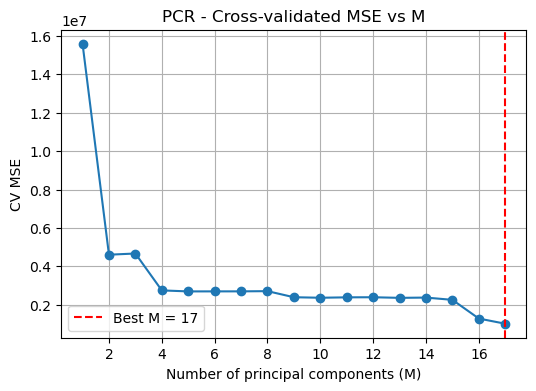

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(Ms, cv_mse, marker='o')
plt.axvline(best_M, linestyle='--', color='red', label=f'Best M = {best_M}')
plt.xlabel("Number of principal components (M)")
plt.ylabel("CV MSE")
plt.title("PCR - Cross-validated MSE vs M")
plt.legend()
plt.grid(True)
plt.show()
